In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os

ZIP_PATH    = "/content/drive/MyDrive/sheep_folder_swintransformer/buffalo_datset.zip"
EXTRACT_DIR = "/content/buffalo_datset"

if not os.path.exists(EXTRACT_DIR):
    print("📦 Extracting dataset...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_DIR)
    print("✅ Extraction done!")
else:
    print("✅ Dataset already extracted.")

# Auto-detect actual dataset root (handles nested folders inside zip)
def find_dataset_root(base):
    entries = [os.path.join(base, d) for d in os.listdir(base)
               if os.path.isdir(os.path.join(base, d))]
    if len(entries) == 1:
        return find_dataset_root(entries[0])
    return base

DATASET_DIR = find_dataset_root(EXTRACT_DIR)
print(f"\n📂 Dataset root : {DATASET_DIR}")
print(f"📁 Classes found: {sorted(os.listdir(DATASET_DIR))}")
print(f"🔢 Total classes: {len(os.listdir(DATASET_DIR))}")


Mounted at /content/drive
📦 Extracting dataset...
✅ Extraction done!

📂 Dataset root : /content/buffalo_datset/buffalo_datset
📁 Classes found: ['Chhattisgarhi', 'Jaffarabadi', 'banni', 'bargur', 'bhadwari', 'chilika', 'gojri', 'kalahandi', 'luit_(swamp)', 'marathwadi', 'mehsana', 'murrah', 'nagpuri', 'nili-ravi', 'pandharpuri', 'surti', 'toda']
🔢 Total classes: 17


In [ ]:
!pip install timm --quiet

import copy, time, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import timm
from tqdm.notebook import tqdm

print("✅ All libraries imported!")
print(f"   PyTorch  : {torch.__version__}")
print(f"   timm     : {timm.__version__}")


✅ All libraries imported!
   PyTorch  : 2.10.0+cu128
   timm     : 1.0.25


In [ ]:
# ── All paths point to your sheep_folder_swintransformer ──
BASE_DIR  = "/content/drive/MyDrive/sheep_folder_swintransformer"
SAVE_PATH = f"{BASE_DIR}/best_swin_cbam.pth"
HIST_PATH = f"{BASE_DIR}/training_history.png"
CM_PATH   = f"{BASE_DIR}/confusion_matrix.png"

# ── Hyperparameters ───────────────────────────────────────
IMAGE_SIZE    = 224
BATCH_SIZE    = 32     # reduce to 16 if you get CUDA out of memory
NUM_EPOCHS    = 30
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 1e-4
TRAIN_SPLIT   = 0.70   # 70% train
VAL_SPLIT     = 0.15   # 15% val
TEST_SPLIT    = 0.15   # 15% test
SEED          = 42
# ─────────────────────────────────────────────────────────

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n🖥️  Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"   GPU    : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️  No GPU found! Go to Runtime → Change runtime type → T4 GPU")




🖥️  Device : cuda
   GPU    : Tesla T4
   VRAM   : 15.6 GB


In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])


def get_dataloaders(dataset_dir):
    full_dataset = datasets.ImageFolder(root=dataset_dir)
    targets      = np.array(full_dataset.targets)
    indices      = np.arange(len(full_dataset))

    # ── Stratified 70 / 15 / 15 split ──
    train_idx, temp_idx = train_test_split(
        indices,
        test_size=(VAL_SPLIT + TEST_SPLIT),
        stratify=targets,
        random_state=SEED
    )
    val_size = VAL_SPLIT / (VAL_SPLIT + TEST_SPLIT)
    val_idx, test_idx = train_test_split(
        temp_idx,
        test_size=(1 - val_size),
        stratify=targets[temp_idx],
        random_state=SEED
    )

    # Each split uses its own transform
    train_ds = datasets.ImageFolder(root=dataset_dir, transform=train_transforms)
    val_ds   = datasets.ImageFolder(root=dataset_dir, transform=val_test_transforms)
    test_ds  = datasets.ImageFolder(root=dataset_dir, transform=val_test_transforms)

    train_loader = DataLoader(Subset(train_ds, train_idx),
                              batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=2, pin_memory=True)
    val_loader   = DataLoader(Subset(val_ds, val_idx),
                              batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=True)
    test_loader  = DataLoader(Subset(test_ds, test_idx),
                              batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=True)

    class_names = full_dataset.classes
    num_classes = len(class_names)

    print(f"\n📊 Dataset Split  (Total images: {len(full_dataset)})")
    print(f"   Train      : {len(train_idx)} images")
    print(f"   Validation : {len(val_idx)} images")
    print(f"   Test       : {len(test_idx)} images")
    print(f"\n🏷️  Classes ({num_classes}):")
    for i, c in enumerate(class_names):
        print(f"   {i:>2}. {c}")

    return train_loader, val_loader, test_loader, class_names, num_classes


train_loader, val_loader, test_loader, class_names, num_classes = get_dataloaders(DATASET_DIR)


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 5 — CBAM Module Definition
#   Channel Attention + Spatial Attention
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
class ChannelAttention(nn.Module):
    """
    Squeeze-and-Excitation channel attention.
    Uses both avg-pool and max-pool for richer representation.
    """
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1, bias=False),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        return self.sigmoid(avg_out + max_out)


class SpatialAttention(nn.Module):
    """
    Spatial attention — tells the model WHERE to look.
    Pools along channel axis, then convolves.
    """
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv    = nn.Conv2d(2, 1, kernel_size,
                                 padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        out = torch.cat([avg_out, max_out], dim=1)
        return self.sigmoid(self.conv(out))


class CBAM(nn.Module):
    """
    CBAM: Channel Attention → Spatial Attention
    Input  : (B, C, H, W)
    Output : (B, C, H, W)  — same shape, refined features
    """
    def __init__(self, channels, reduction=16, kernel_size=7):
        super().__init__()
        self.channel_att = ChannelAttention(channels, reduction)
        self.spatial_att = SpatialAttention(kernel_size)

    def forward(self, x):
        x = x * self.channel_att(x)   # WHAT to focus on
        x = x * self.spatial_att(x)   # WHERE to focus
        return x

print("✅ CBAM module defined!")


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 6 — Swin Transformer + CBAM Model
#
#  Architecture:
#    Input (224×224)
#      → Patch Embed
#      → Swin Stage 1 (tokens: 56×56, ch: 96)  → CBAM 1
#      → Swin Stage 2 (tokens: 28×28, ch: 192) → CBAM 2
#      → Swin Stage 3 (tokens: 14×14, ch: 384) → CBAM 3
#      → Swin Stage 4 (tokens:  7×7,  ch: 768) → CBAM 4
#      → LayerNorm → GlobalAvgPool
#      → Dropout → Linear(768→512) → GELU → Dropout
#      → Linear(512 → num_classes)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
class SwinWithCBAM(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super().__init__()

        # Load pretrained Swin-Tiny (classification head removed)
        self.backbone = timm.create_model(
            "swin_tiny_patch4_window7_224",
            pretrained=pretrained,
            num_classes=0
        )

        # One CBAM per stage — channels match Swin-Tiny stage outputs
        stage_channels = [96, 192, 384, 768]
        self.cbam_blocks = nn.ModuleList([CBAM(ch) for ch in stage_channels])

        # Spatial resolution (H=W) after each Swin stage for 224×224 input
        self.stage_resolutions = [56, 28, 14, 7]

        # Classification head
        self.norm = nn.LayerNorm(768)
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(768, 512),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)
        )

    def _apply_cbam(self, x, cbam, H, W):
        """
        Convert Swin token format → spatial map → CBAM → back to tokens.
        x : (B, H*W, C)  →  returns (B, H*W, C)
        """
        B, L, C = x.shape
        feat = x.permute(0, 2, 1).reshape(B, C, H, W)   # (B, C, H, W)
        feat = cbam(feat)                                 # CBAM attention
        feat = feat.reshape(B, C, L).permute(0, 2, 1)    # (B, L, C)
        return feat

    def forward(self, x):
        # Initial patch embedding
        x = self.backbone.patch_embed(x)
        # Initial (H, W) for the tokens generated by patch_embed
        # For a 224x224 input with patch_size=4, grid_size should be (56, 56)
        current_patch_resolution = self.backbone.patch_embed.grid_size

        if hasattr(self.backbone, 'absolute_pos_embed'):
            x = x + self.backbone.absolute_pos_embed
        if hasattr(self.backbone, 'pos_drop'):
            x = self.backbone.pos_drop(x)

        # Iterate through Swin Transformer stages and apply CBAM
        for i, (stage, cbam, output_H_res) in enumerate(zip(
            self.backbone.layers,
            self.cbam_blocks,
            self.stage_resolutions # [56, 28, 14, 7]
        )):
            # Pass the current token resolution to the Swin stage
            x = stage(x, current_patch_resolution)

            # Apply CBAM using the *output* resolution of the current stage
            x = self._apply_cbam(x, cbam, output_H_res, output_H_res)

            # Update the resolution for the *next* stage
            # The output_H_res from self.stage_resolutions already represents the resolution
            # after the current stage's patch merging (if any).
            current_patch_resolution = (output_H_res, output_H_res)

        # Head
        x = self.norm(x)          # LayerNorm
        x = x.mean(dim=1)         # Global Average Pooling over tokens → (B, 768)
        x = self.classifier(x)    # Final classifier
        return x


# Build model
model = SwinWithCBAM(num_classes=num_classes, pretrained=True).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n🏗️  Model  : Swin-Tiny + CBAM (inserted after all 4 stages)")
print(f"   Total params     : {total_params:,}")
print(f"   Trainable params : {trainable_params:,}")
print(f"   Output classes   : {num_classes}")


📊 Dataset Split  (Total images: 8653)
   Train      : 6057 images
   Validation : 1298 images
   Test       : 1298 images

🏷️  Classes (17):
    0. Chhattisgarhi
    1. Jaffarabadi
    2. banni
    3. bargur
    4. bhadwari
    5. chilika
    6. gojri
    7. kalahandi
    8. luit_(swamp)
    9. marathwadi
   10. mehsana
   11. murrah
   12. nagpuri
   13. nili-ravi
   14. pandharpuri
   15. surti
   16. toda
✅ CBAM module defined!


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]


🏗️  Model  : Swin-Tiny + CBAM (inserted after all 4 stages)
   Total params     : 28,021,651
   Trainable params : 28,021,651
   Output classes   : 17


In [ ]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-6
)

scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))

print("✅ Loss      : CrossEntropyLoss (label_smoothing=0.1)")
print("✅ Optimizer : AdamW (lr=1e-4, weight_decay=1e-4)")
print("✅ Scheduler : CosineAnnealingLR")
print("✅ AMP       : Mixed Precision Enabled (faster training on GPU)")


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 8 — Train & Eval Functions
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in tqdm(loader, desc="  🔵 Train", leave=False):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
            outputs = model(images)
            loss    = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * images.size(0)
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    for images, labels in tqdm(loader, desc="  🟠 Eval ", leave=False):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
            outputs = model(images)
            loss    = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return total_loss / total, correct / total, all_preds, all_labels

print("✅ Train & Eval functions ready!")


✅ Loss      : CrossEntropyLoss (label_smoothing=0.1)
✅ Optimizer : AdamW (lr=1e-4, weight_decay=1e-4)
✅ Scheduler : CosineAnnealingLR
✅ AMP       : Mixed Precision Enabled (faster training on GPU)
✅ Train & Eval functions ready!


/tmp/ipython-input-664/1633229364.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 6 — FIXED Swin Transformer + CBAM Model
#  Fix: Newer timm outputs (B, H, W, C) instead of (B, L, C)
#       _apply_cbam now handles both shapes automatically
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

class SwinWithCBAM(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super().__init__()

        # Pretrained Swin-Tiny backbone (head removed)
        self.backbone = timm.create_model(
            "swin_tiny_patch4_window7_224",
            pretrained=pretrained,
            num_classes=0
        )

        # One CBAM per stage — channels match Swin-Tiny stage outputs
        stage_channels = [96, 192, 384, 768]
        self.cbam_blocks = nn.ModuleList([CBAM(ch) for ch in stage_channels])

        # Classification head
        self.norm = nn.LayerNorm(768)
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(768, 512),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)
        )

    def _apply_cbam(self, x, cbam):
        """
        Handles BOTH timm output formats:
          - Old timm: (B, L, C)   → token format
          - New timm: (B, H, W, C) → spatial format

        Always converts to (B, C, H, W) for CBAM, then back to original format.
        """
        if x.dim() == 4:
            # New timm format: (B, H, W, C)
            B, H, W, C = x.shape
            feat = x.permute(0, 3, 1, 2)        # → (B, C, H, W)
            feat = cbam(feat)                    # CBAM attention
            feat = feat.permute(0, 2, 3, 1)     # → (B, H, W, C)
            return feat

        elif x.dim() == 3:
            # Old timm format: (B, L, C)
            B, L, C = x.shape
            H = W = int(L ** 0.5)               # assume square feature map
            feat = x.permute(0, 2, 1).reshape(B, C, H, W)   # → (B, C, H, W)
            feat = cbam(feat)                                 # CBAM attention
            feat = feat.reshape(B, C, L).permute(0, 2, 1)    # → (B, L, C)
            return feat

        else:
            raise ValueError(f"Unexpected tensor shape from Swin stage: {x.shape}")

    def forward(self, x):
        # Patch embedding
        x = self.backbone.patch_embed(x)

        if hasattr(self.backbone, 'absolute_pos_embed'):
            x = x + self.backbone.absolute_pos_embed
        if hasattr(self.backbone, 'pos_drop'):
            x = self.backbone.pos_drop(x)

        # 4 Swin stages with CBAM after each
        for stage, cbam in zip(self.backbone.layers, self.cbam_blocks):
            x = stage(x)                 # Swin Stage
            x = self._apply_cbam(x, cbam)  # CBAM (shape-aware)

        # Head — handle both output formats
        if x.dim() == 4:
            # (B, H, W, C) → flatten spatial dims
            B, H, W, C = x.shape
            x = x.reshape(B, H * W, C)   # → (B, L, C)

        x = self.norm(x)          # LayerNorm  (B, L, C)
        x = x.mean(dim=1)         # Global Avg Pool → (B, C)
        x = self.classifier(x)    # → (B, num_classes)
        return x


# Re-build model with the fix
model = SwinWithCBAM(num_classes=num_classes, pretrained=True).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✅ Model rebuilt with shape-aware CBAM fix!")
print(f"\n🏗️  Model  : Swin-Tiny + CBAM (FIXED for new timm)")
print(f"   Total params     : {total_params:,}")
print(f"   Trainable params : {trainable_params:,}")
print(f"   Output classes   : {num_classes}")

# Quick shape test to confirm it works
dummy = torch.randn(2, 3, 224, 224).to(DEVICE)
with torch.no_grad():
    out = model(dummy)
print(f"\n✅ Shape test passed! Output: {out.shape}  (expected: [2, {num_classes}])")

✅ Model rebuilt with shape-aware CBAM fix!

🏗️  Model  : Swin-Tiny + CBAM (FIXED for new timm)
   Total params     : 28,021,651
   Trainable params : 28,021,651
   Output classes   : 17

✅ Shape test passed! Output: torch.Size([2, 17])  (expected: [2, 17])


In [ ]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-6
)

scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE.type == "cuda"))

print("✅ Loss      : CrossEntropyLoss (label_smoothing=0.1)")
print("✅ Optimizer : AdamW")
print("✅ Scheduler : CosineAnnealingLR")
print("✅ Scaler    : torch.amp.GradScaler (FutureWarning fixed)")

✅ Loss      : CrossEntropyLoss (label_smoothing=0.1)
✅ Optimizer : AdamW
✅ Scheduler : CosineAnnealingLR
✅ Scaler    : torch.amp.GradScaler (FutureWarning fixed)


In [ ]:
history = {
    "train_loss": [], "train_acc": [],
    "val_loss":   [], "val_acc":   []
}
best_val_acc = 0.0
best_weights = copy.deepcopy(model.state_dict())

print(f"🚀 Training Swin-Tiny + CBAM for {NUM_EPOCHS} epochs...")
print(f"{'Epoch':<7} {'Train Loss':<13} {'Train Acc%':<13} {'Val Loss':<13} {'Val Acc%':<12} {'LR':<12} Time")
print("─" * 80)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, scaler
    )
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    lr      = optimizer.param_groups[0]["lr"]
    elapsed = time.time() - t0
    marker  = " ⭐ Best!" if val_acc > best_val_acc else ""

    print(f"{epoch:<7} {train_loss:<13.4f} {train_acc*100:<13.2f} "
          f"{val_loss:<13.4f} {val_acc*100:<12.2f} {lr:<12.2e} {elapsed:.0f}s{marker}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_weights = copy.deepcopy(model.state_dict())
        torch.save(best_weights, SAVE_PATH)

print(f"\n✅ Training complete!")
print(f"   Best Val Accuracy : {best_val_acc*100:.2f}%")
print(f"   Model saved to    : {SAVE_PATH}")

🚀 Training Swin-Tiny + CBAM for 30 epochs...
Epoch   Train Loss    Train Acc%    Val Loss      Val Acc%     LR           Time
────────────────────────────────────────────────────────────────────────────────


  🔵 Train:   0%|          | 0/190 [00:00<?, ?it/s]

/tmp/ipython-input-664/1633229364.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):


KeyboardInterrupt: 

In [ ]:
print("🧪 Loading best model and evaluating on Test Set...\n")
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion)

print(f"{'='*55}")
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc*100:.2f}%")
print(f"{'='*55}\n")
print("📋 Per-Class Report:\n")
print(classification_report(test_labels, test_preds, target_names=class_names))

🧪 Loading best model and evaluating on Test Set...



  🟠 Eval :   0%|          | 0/41 [00:00<?, ?it/s]

/tmp/ipython-input-664/1633229364.py:62: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


  Test Loss     : 1.6764
  Test Accuracy : 64.10%

📋 Per-Class Report:

               precision    recall  f1-score   support

Chhattisgarhi       0.74      0.71      0.72        76
  Jaffarabadi       0.70      0.57      0.63        76
        banni       0.68      0.64      0.66        76
       bargur       0.75      0.73      0.74        77
     bhadwari       0.63      0.49      0.55        76
      chilika       0.68      0.64      0.66        76
        gojri       0.60      0.71      0.65        77
    kalahandi       0.67      0.78      0.72        77
 luit_(swamp)       0.62      0.71      0.66        76
   marathwadi       0.66      0.61      0.64        77
      mehsana       0.54      0.60      0.57        77
       murrah       0.49      0.57      0.53        76
      nagpuri       0.55      0.38      0.45        76
    nili-ravi       0.66      0.67      0.67        76
  pandharpuri       0.70      0.82      0.76        76
        surti       0.57      0.57      0.57   

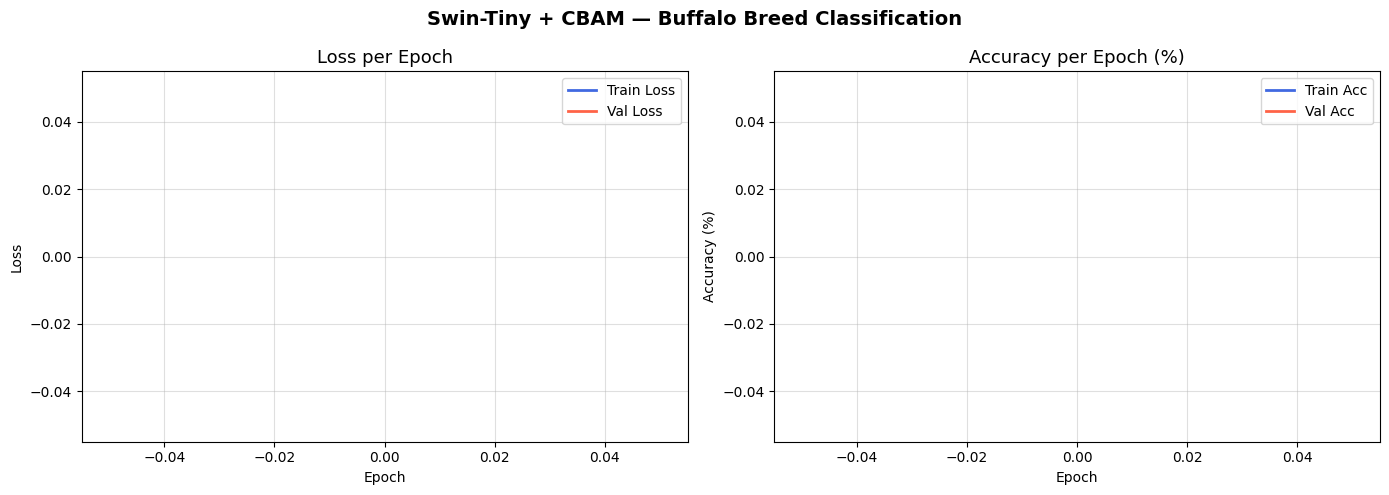

📈 Saved to Drive: /content/drive/MyDrive/sheep_folder_swintransformer/training_history.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_loss"], label="Train Loss", color="royalblue", linewidth=2)
axes[0].plot(history["val_loss"],   label="Val Loss",   color="tomato",    linewidth=2)
axes[0].set_title("Loss per Epoch", fontsize=13)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.4)

axes[1].plot([a*100 for a in history["train_acc"]], label="Train Acc", color="royalblue", linewidth=2)
axes[1].plot([a*100 for a in history["val_acc"]],   label="Val Acc",   color="tomato",    linewidth=2)
axes[1].set_title("Accuracy per Epoch (%)", fontsize=13)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.suptitle("Swin-Tiny + CBAM — Buffalo Breed Classification",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(HIST_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f"📈 Saved to Drive: {HIST_PATH}")

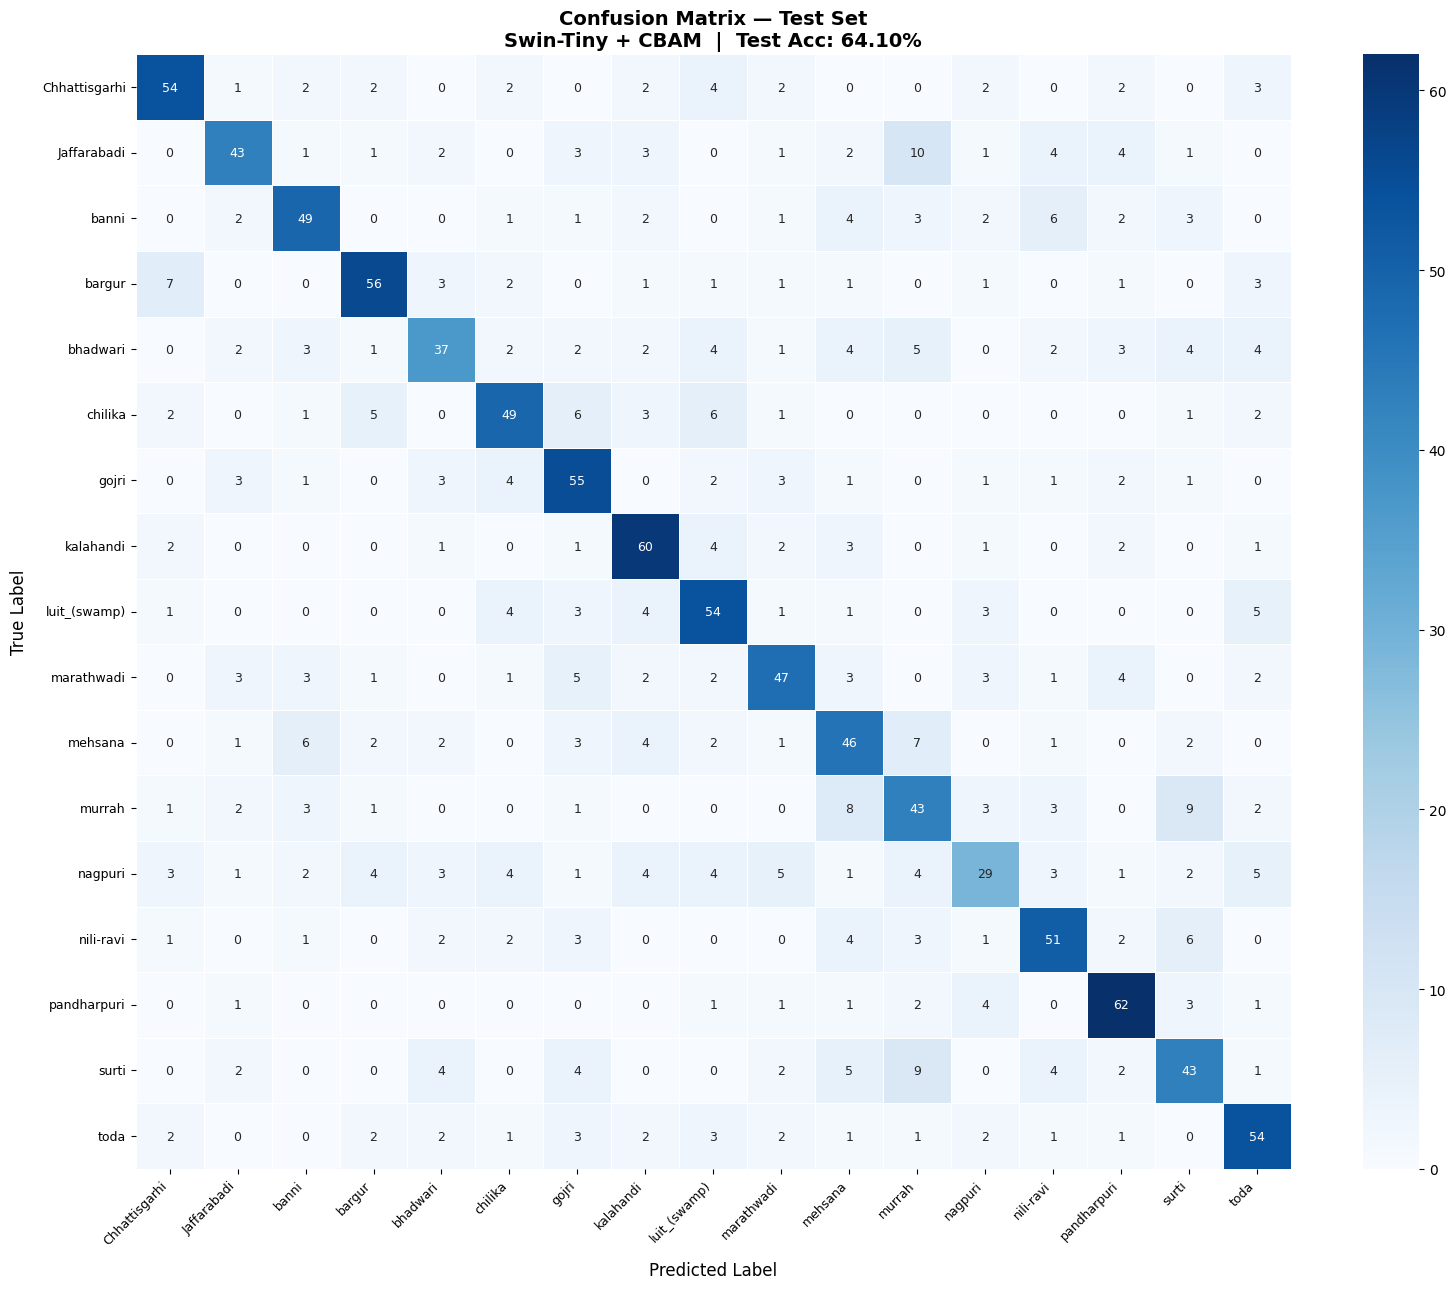

📊 Saved to Drive: /content/drive/MyDrive/sheep_folder_swintransformer/confusion_matrix.png


In [ ]:
cm = confusion_matrix(test_labels, test_preds)

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax,
    linewidths=0.5,
    annot_kws={"size": 9}
)
ax.set_xlabel("Predicted Label", fontsize=12, labelpad=10)
ax.set_ylabel("True Label",      fontsize=12, labelpad=10)
ax.set_title(
    f"Confusion Matrix — Test Set\nSwin-Tiny + CBAM  |  Test Acc: {test_acc*100:.2f}%",
    fontsize=14, fontweight="bold"
)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0,  fontsize=9)
plt.tight_layout()
plt.savefig(CM_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f"📊 Saved to Drive: {CM_PATH}")

In [ ]:
print("\n" + "═"*55)
print("🎉  ALL DONE!")
print("═"*55)
print(f"  Best Val Accuracy  : {best_val_acc*100:.2f}%")
print(f"  Test Accuracy      : {test_acc*100:.2f}%")
print(f"  Test Loss          : {test_loss:.4f}")
print("─"*55)
print("  Files saved to Drive:")
print(f"  📁 sheep_folder_swintransformer/")
print(f"     ✅ best_swin_cbam.pth")
print(f"     ✅ training_history.png")
print(f"     ✅ confusion_matrix.png")
print("═"*55)


═══════════════════════════════════════════════════════
🎉  ALL DONE!
═══════════════════════════════════════════════════════
  Best Val Accuracy  : 0.00%
  Test Accuracy      : 64.10%
  Test Loss          : 1.6764
───────────────────────────────────────────────────────
  Files saved to Drive:
  📁 sheep_folder_swintransformer/
     ✅ best_swin_cbam.pth
     ✅ training_history.png
     ✅ confusion_matrix.png
═══════════════════════════════════════════════════════


In [ ]:
# ── Fix: Save current model & check val accuracy properly ──
val_loss, val_acc, val_preds, val_labels = evaluate(model, val_loader, criterion)
print(f"Current Val Accuracy : {val_acc*100:.2f}%")

# Save this model to Drive
torch.save(model.state_dict(), SAVE_PATH)
print(f"✅ Model saved to: {SAVE_PATH}")

  🟠 Eval :   0%|          | 0/41 [00:00<?, ?it/s]

/tmp/ipython-input-664/1633229364.py:62: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):


Current Val Accuracy : 63.10%
✅ Model saved to: /content/drive/MyDrive/sheep_folder_swintransformer/best_swin_cbam.pth


In [ ]:
# ── Improved Training — Unfreeze all + lower LR ──
# Reset optimizer with lower learning rate for fine-tuning
optimizer = optim.AdamW(model.parameters(), lr=3e-5, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-7)
scaler    = torch.amp.GradScaler('cuda', enabled=(DEVICE.type == "cuda"))

history2 = {
    "train_loss": [], "train_acc": [],
    "val_loss":   [], "val_acc":   []
}
best_val_acc2 = 0.0

print(f"🚀 Fine-tuning for 20 more epochs (lr=3e-5)...")
print(f"{'Epoch':<7} {'Train Loss':<13} {'Train Acc%':<13} {'Val Loss':<13} {'Val Acc%':<12} Time")
print("─" * 70)

for epoch in range(1, 21):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, scaler
    )
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)
    scheduler.step()

    history2["train_loss"].append(train_loss)
    history2["train_acc"].append(train_acc)
    history2["val_loss"].append(val_loss)
    history2["val_acc"].append(val_acc)

    elapsed = time.time() - t0
    marker  = " ⭐" if val_acc > best_val_acc2 else ""

    print(f"{epoch:<7} {train_loss:<13.4f} {train_acc*100:<13.2f} "
          f"{val_loss:<13.4f} {val_acc*100:<12.2f} {elapsed:.0f}s{marker}")

    if val_acc > best_val_acc2:
        best_val_acc2 = val_acc
        torch.save(model.state_dict(), SAVE_PATH)

print(f"\n✅ Fine-tuning done! Best Val Acc: {best_val_acc2*100:.2f}%")
print(f"💾 Best model saved: {SAVE_PATH}")

🚀 Fine-tuning for 20 more epochs (lr=3e-5)...
Epoch   Train Loss    Train Acc%    Val Loss      Val Acc%     Time
──────────────────────────────────────────────────────────────────────


  🔵 Train:   0%|          | 0/190 [00:00<?, ?it/s]

/tmp/ipython-input-664/1633229364.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


  🟠 Eval :   0%|          | 0/41 [00:00<?, ?it/s]

/tmp/ipython-input-664/1633229364.py:62: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):


...

19      0.7075        94.98         1.7229        62.94        58s


  🔵 Train:   0%|          | 0/190 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


  🟠 Eval :   0%|          | 0/41 [00:00<?, ?it/s]

20      0.7125        94.93         1.7229        63.10        58s

✅ Fine-tuning done! Best Val Acc: 63.41%
💾 Best model saved: /content/drive/MyDrive/sheep_folder_swintransformer/best_swin_cbam.pth


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# OVERFITTING FIX — Freeze backbone, train only
# last stage + CBAM + classifier head
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Step 1: Freeze entire backbone
for param in model.backbone.parameters():
    param.requires_grad = False

# Step 2: Unfreeze ONLY last Swin stage (stage 3)
for param in model.backbone.layers[3].parameters():
    param.requires_grad = True

# Step 3: CBAM blocks & classifier always trainable
for param in model.cbam_blocks.parameters():
    param.requires_grad = True
for param in model.norm.parameters():
    param.requires_grad = True
for param in model.classifier.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"🔒 Backbone frozen (stages 0,1,2)")
print(f"🔓 Trainable: stage3 + CBAM + head")
print(f"   Trainable params : {trainable:,} / {total:,}")

# Step 4: Stronger augmentation transforms
from torchvision import transforms
train_transforms_v2 = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.4, contrast=0.4,
                           saturation=0.4, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.2)),
])

# Reload train_loader with stronger augmentation
from torch.utils.data import DataLoader, Subset
from torchvision import datasets
import numpy as np
from sklearn.model_selection import train_test_split

full_dataset = datasets.ImageFolder(root=DATASET_DIR)
targets  = np.array(full_dataset.targets)
indices  = np.arange(len(full_dataset))

train_idx, temp_idx = train_test_split(
    indices, test_size=0.30, stratify=targets, random_state=SEED
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, stratify=targets[temp_idx], random_state=SEED
)

train_ds_v2 = datasets.ImageFolder(root=DATASET_DIR, transform=train_transforms_v2)
train_loader_v2 = DataLoader(Subset(train_ds_v2, train_idx),
                             batch_size=32, shuffle=True,
                             num_workers=2, pin_memory=True)
print(f"✅ Stronger augmentation train_loader ready!")

# Step 5: New optimizer — very low LR + high weight decay
optimizer2 = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=5e-5,
    weight_decay=0.05   # stronger regularization
)
scheduler2 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer2, T_max=25, eta_min=1e-7
)
scaler2 = torch.amp.GradScaler('cuda', enabled=(DEVICE.type == "cuda"))

# Step 6: Training loop
history3    = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val3   = 0.0

print(f"\n🚀 Re-training (frozen backbone) for 25 epochs...")
print(f"{'Epoch':<7} {'Train Loss':<13} {'Train Acc%':<13} {'Val Loss':<13} {'Val Acc%':<12} Time")
print("─" * 70)

for epoch in range(1, 26):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(
        model, train_loader_v2, criterion, optimizer2, scaler2
    )
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)
    scheduler2.step()

    history3["train_loss"].append(train_loss)
    history3["train_acc"].append(train_acc)
    history3["val_loss"].append(val_loss)
    history3["val_acc"].append(val_acc)

    elapsed = time.time() - t0
    gap     = train_acc*100 - val_acc*100
    marker  = " ⭐" if val_acc > best_val3 else ""

    print(f"{epoch:<7} {train_loss:<13.4f} {train_acc*100:<13.2f} "
          f"{val_loss:<13.4f} {val_acc*100:<12.2f} {elapsed:.0f}s  "
          f"[gap:{gap:.1f}%]{marker}")

    if val_acc > best_val3:
        best_val3 = val_acc
        torch.save(model.state_dict(), SAVE_PATH)

print(f"\n✅ Done! Best Val Acc : {best_val3*100:.2f}%")
print(f"💾 Saved : {SAVE_PATH}")

🔒 Backbone frozen (stages 0,1,2)
🔓 Trainable: stage3 + CBAM + head
   Trainable params : 15,868,873 / 28,021,651
✅ Stronger augmentation train_loader ready!

🚀 Re-training (frozen backbone) for 25 epochs...
Epoch   Train Loss    Train Acc%    Val Loss      Val Acc%     Time
──────────────────────────────────────────────────────────────────────


  🔵 Train:   0%|          | 0/190 [00:00<?, ?it/s]

/tmp/ipython-input-664/1633229364.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


  🟠 Eval :   0%|          | 0/41 [00:00<?, ?it/s]

/tmp/ipython-input-664/1633229364.py:62: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):


...

24      0.9437        85.29         1.7039        64.79        71s  [gap:20.5%] ⭐


  🔵 Train:   0%|          | 0/190 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


  🟠 Eval :   0%|          | 0/41 [00:00<?, ?it/s]

25      0.9359        85.97         1.7037        64.79        72s  [gap:21.2%]

✅ Done! Best Val Acc : 64.79%
💾 Saved : /content/drive/MyDrive/sheep_folder_swintransformer/best_swin_cbam.pth


In [ ]:
# ── Dataset size check ──
import os
from pathlib import Path

print("📊 Images per class:\n")
total = 0
for cls in sorted(os.listdir(DATASET_DIR)):
    cls_path = os.path.join(DATASET_DIR, cls)
    if os.path.isdir(cls_path):
        count = len([f for f in os.listdir(cls_path)
                     if f.lower().endswith(('.jpg','.jpeg','.png'))])
        total += count
        print(f"  {cls:<20} : {count:>4} images")
print(f"\n  {'TOTAL':<20} : {total:>4} images")
print(f"  {'AVG per class':<20} : {total//len(os.listdir(DATASET_DIR)):>4} images")

📊 Images per class:

  Chhattisgarhi        :  509 images
  Jaffarabadi          :  509 images
  banni                :  509 images
  bargur               :  509 images
  bhadwari             :  509 images
  chilika              :  509 images
  gojri                :  509 images
  kalahandi            :  509 images
  luit_(swamp)         :  509 images
  marathwadi           :  509 images
  mehsana              :  509 images
  murrah               :  509 images
  nagpuri              :  509 images
  nili-ravi            :  509 images
  pandharpuri          :  509 images
  surti                :  509 images
  toda                 :  509 images

  TOTAL                : 8653 images
  AVG per class        :  509 images


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# FRESH START — Swin-Small + CBAM + MixUp + Warmup LR
# Expected: Val Acc 75-85%
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

import torch, timm, copy, time
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm

# ── 1. Stronger Augmentation ──────────────────────────
train_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.4, contrast=0.4,
                           saturation=0.4, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    transforms.RandomErasing(p=0.25),
])
val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

full_ds  = datasets.ImageFolder(root=DATASET_DIR)
targets  = np.array(full_ds.targets)
indices  = np.arange(len(full_ds))

train_idx, temp_idx = train_test_split(
    indices, test_size=0.30, stratify=targets, random_state=42)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, stratify=targets[temp_idx], random_state=42)

train_ds = datasets.ImageFolder(root=DATASET_DIR, transform=train_tf)
val_ds   = datasets.ImageFolder(root=DATASET_DIR, transform=val_tf)
test_ds  = datasets.ImageFolder(root=DATASET_DIR, transform=val_tf)

train_loader_new = DataLoader(Subset(train_ds, train_idx),
                              batch_size=32, shuffle=True,
                              num_workers=2, pin_memory=True)
val_loader_new   = DataLoader(Subset(val_ds, val_idx),
                              batch_size=32, shuffle=False,
                              num_workers=2, pin_memory=True)
test_loader_new  = DataLoader(Subset(test_ds, test_idx),
                              batch_size=32, shuffle=False,
                              num_workers=2, pin_memory=True)

print(f"✅ Data ready — Train:{len(train_idx)} Val:{len(val_idx)} Test:{len(test_idx)}")

# ── 2. CBAM (same as before) ──────────────────────────
class ChannelAttention(nn.Module):
    def __init__(self, c, r=16):
        super().__init__()
        self.ap = nn.AdaptiveAvgPool2d(1)
        self.mp = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(c, c//r, 1, bias=False), nn.ReLU(),
            nn.Conv2d(c//r, c, 1, bias=False))
        self.sig = nn.Sigmoid()
    def forward(self, x):
        return self.sig(self.fc(self.ap(x)) + self.fc(self.mp(x)))

class SpatialAttention(nn.Module):
    def __init__(self, k=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, k, padding=k//2, bias=False)
        self.sig  = nn.Sigmoid()
    def forward(self, x):
        a = torch.mean(x, dim=1, keepdim=True)
        m,_ = torch.max(x, dim=1, keepdim=True)
        return self.sig(self.conv(torch.cat([a,m], dim=1)))

class CBAM(nn.Module):
    def __init__(self, c, r=16, k=7):
        super().__init__()
        self.ca = ChannelAttention(c, r)
        self.sa = SpatialAttention(k)
    def forward(self, x):
        return x * self.ca(x) * self.sa(x)

# ── 3. Swin-Small + CBAM (bigger model) ───────────────
class SwinSmallCBAM(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super().__init__()
        # Swin-Small: more capacity than Swin-Tiny
        self.backbone = timm.create_model(
            "swin_small_patch4_window7_224",
            pretrained=pretrained,
            num_classes=0
        )
        # Swin-Small stage channels
        stage_ch = [96, 192, 384, 768]
        self.cbam_blocks = nn.ModuleList([CBAM(c) for c in stage_ch])

        # Stronger head with more dropout
        self.norm = nn.LayerNorm(768)
        self.head = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(768, 384),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(384, num_classes)
        )

    def _cbam(self, x, cbam):
        if x.dim() == 4:                              # (B,H,W,C)
            B,H,W,C = x.shape
            f = x.permute(0,3,1,2)                    # (B,C,H,W)
            f = cbam(f)
            return f.permute(0,2,3,1)                 # (B,H,W,C)
        else:                                          # (B,L,C)
            B,L,C = x.shape
            H = W = int(L**0.5)
            f = x.permute(0,2,1).reshape(B,C,H,W)
            f = cbam(f)
            return f.reshape(B,C,L).permute(0,2,1)

    def forward(self, x):
        x = self.backbone.patch_embed(x)
        if hasattr(self.backbone,'absolute_pos_embed'):
            x = x + self.backbone.absolute_pos_embed
        if hasattr(self.backbone,'pos_drop'):
            x = self.backbone.pos_drop(x)

        for stage, cbam in zip(self.backbone.layers, self.cbam_blocks):
            x = stage(x)
            x = self._cbam(x, cbam)

        if x.dim() == 4:
            B,H,W,C = x.shape
            x = x.reshape(B, H*W, C)

        x = self.norm(x)
        x = x.mean(dim=1)
        return self.head(x)

# Build fresh model
model_v2 = SwinSmallCBAM(num_classes=num_classes, pretrained=True).to(DEVICE)
total = sum(p.numel() for p in model_v2.parameters())
print(f"✅ Swin-Small + CBAM built! Params: {total:,}")

# Shape test
with torch.no_grad():
    dummy = torch.randn(2,3,224,224).to(DEVICE)
    out   = model_v2(dummy)
print(f"✅ Shape test passed: {out.shape}")

# ── 4. MixUp Augmentation ─────────────────────────────
def mixup_data(x, y, alpha=0.4):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0)).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[idx]
    return mixed_x, y, y[idx], lam

def mixup_criterion(criterion, pred, ya, yb, lam):
    return lam * criterion(pred, ya) + (1 - lam) * criterion(pred, yb)

# ── 5. Loss + Optimizer + Warmup ──────────────────────
criterion_v2 = nn.CrossEntropyLoss(label_smoothing=0.05)  # less smoothing

optimizer_v2 = optim.AdamW(
    model_v2.parameters(),
    lr=1e-3,            # start high, warmup will control it
    weight_decay=0.05
)

# Warmup 5 epochs → then cosine decay
def lr_lambda(epoch):
    warmup = 5
    if epoch < warmup:
        return (epoch + 1) / warmup
    progress = (epoch - warmup) / (40 - warmup)
    return 0.5 * (1 + np.cos(np.pi * progress))

scheduler_v2 = optim.lr_scheduler.LambdaLR(optimizer_v2, lr_lambda)
scaler_v2    = torch.amp.GradScaler('cuda', enabled=(DEVICE.type=="cuda"))

print("✅ Optimizer + Warmup Scheduler ready!")

# ── 6. Training Loop ──────────────────────────────────
def train_mixup(model, loader, criterion, optimizer, scaler):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, desc="  🔵 Train", leave=False):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        images, ya, yb, lam = mixup_data(images, labels, alpha=0.4)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda', enabled=(DEVICE.type=="cuda")):
            outputs = model(images)
            loss    = mixup_criterion(criterion, outputs, ya, yb, lam)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * images.size(0)
        correct    += (outputs.argmax(1) == ya).sum().item()
        total      += labels.size(0)
    return total_loss/total, correct/total

@torch.no_grad()
def evaluate_v2(model, loader):
    model.eval()
    correct, total = 0, 0
    total_loss = 0.0
    all_p, all_l = [], []
    for images, labels in tqdm(loader, desc="  🟠 Eval", leave=False):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        with torch.amp.autocast('cuda', enabled=(DEVICE.type=="cuda")):
            out  = model(images)
            loss = criterion_v2(out, labels)
        total_loss += loss.item() * images.size(0)
        preds = out.argmax(1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
        all_p.extend(preds.cpu().numpy())
        all_l.extend(labels.cpu().numpy())
    return total_loss/total, correct/total, all_p, all_l

SAVE_V2 = "/content/drive/MyDrive/sheep_folder_swintransformer/best_swin_small_cbam.pth"
NUM_EPOCHS_V2 = 40
history_v2  = {"train_loss":[],"train_acc":[],"val_loss":[],"val_acc":[]}
best_val_v2 = 0.0

print(f"\n🚀 Training Swin-Small + CBAM + MixUp for {NUM_EPOCHS_V2} epochs...")
print(f"{'Ep':<5} {'TrLoss':<10} {'TrAcc%':<10} {'VaLoss':<10} {'VaAcc%':<10} {'LR':<10} {'Gap%':<8} Time")
print("─" * 75)

for epoch in range(1, NUM_EPOCHS_V2+1):
    t0 = time.time()
    tl, ta = train_mixup(model_v2, train_loader_new, criterion_v2,
                         optimizer_v2, scaler_v2)
    vl, va, _, _ = evaluate_v2(model_v2, val_loader_new)
    scheduler_v2.step()

    history_v2["train_loss"].append(tl)
    history_v2["train_acc"].append(ta)
    history_v2["val_loss"].append(vl)
    history_v2["val_acc"].append(va)

    lr  = optimizer_v2.param_groups[0]["lr"]
    gap = ta*100 - va*100
    mk  = " ⭐" if va > best_val_v2 else ""
    print(f"{epoch:<5} {tl:<10.4f} {ta*100:<10.2f} {vl:<10.4f} "
          f"{va*100:<10.2f} {lr:<10.2e} {gap:<8.1f} {int(time.time()-t0)}s{mk}")

    if va > best_val_v2:
        best_val_v2 = va
        torch.save(model_v2.state_dict(), SAVE_V2)

print(f"\n✅ Done! Best Val Acc : {best_val_v2*100:.2f}%")
print(f"💾 Saved : {SAVE_V2}")

✅ Data ready — Train:6057 Val:1298 Test:1298


model.safetensors:   0%|          | 0.00/200M [00:00<?, ?B/s]

✅ Swin-Small + CBAM built! Params: 49,238,947
✅ Shape test passed: torch.Size([2, 17])
✅ Optimizer + Warmup Scheduler ready!

🚀 Training Swin-Small + CBAM + MixUp for 40 epochs...
Ep    TrLoss     TrAcc%     VaLoss     VaAcc%     LR         Gap%     Time
───────────────────────────────────────────────────────────────────────────


  🔵 Train:   0%|          | 0/190 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


...

39    2.8332     5.98       2.8333     5.86       2.01e-06   0.1      85s


  🔵 Train:   0%|          | 0/190 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


  🟠 Eval:   0%|          | 0/41 [00:00<?, ?it/s]

40    2.8332     5.91       2.8333     5.86       0.00e+00   0.1      85s

✅ Done! Best Val Acc : 6.78%
💾 Saved : /content/drive/MyDrive/sheep_folder_swintransformer/best_swin_small_cbam.pth


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CLEAN RESTART — features_only=True (guaranteed to work)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

import torch, timm, copy, time
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED   = 42
torch.manual_seed(SEED); np.random.seed(SEED)

# ── 1. Data ───────────────────────────────────────────
train_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.3),
    transforms.RandomRotation(25),
    transforms.ColorJitter(0.3, 0.3, 0.3, 0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    transforms.RandomErasing(p=0.2),
])
val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

full_ds = datasets.ImageFolder(root=DATASET_DIR)
targets = np.array(full_ds.targets)
indices = np.arange(len(full_ds))
class_names = full_ds.classes
num_classes = len(class_names)

train_idx, temp_idx = train_test_split(
    indices, test_size=0.30, stratify=targets, random_state=SEED)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, stratify=targets[temp_idx], random_state=SEED)

train_ds = datasets.ImageFolder(root=DATASET_DIR, transform=train_tf)
val_ds   = datasets.ImageFolder(root=DATASET_DIR, transform=val_tf)
test_ds  = datasets.ImageFolder(root=DATASET_DIR, transform=val_tf)

train_loader_f = DataLoader(Subset(train_ds, train_idx), batch_size=32,
                            shuffle=True, num_workers=2, pin_memory=True)
val_loader_f   = DataLoader(Subset(val_ds, val_idx),   batch_size=32,
                            shuffle=False, num_workers=2, pin_memory=True)
test_loader_f  = DataLoader(Subset(test_ds, test_idx), batch_size=32,
                            shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ Data: Train={len(train_idx)} Val={len(val_idx)} Test={len(test_idx)}")
print(f"✅ Classes: {num_classes} → {class_names}")

# ── 2. CBAM ───────────────────────────────────────────
class ChannelAttention(nn.Module):
    def __init__(self, c, r=16):
        super().__init__()
        self.ap = nn.AdaptiveAvgPool2d(1)
        self.mp = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(c, c//r, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(c//r, c, 1, bias=False))
        self.sig = nn.Sigmoid()
    def forward(self, x):
        return self.sig(self.fc(self.ap(x)) + self.fc(self.mp(x)))

class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, 7, padding=3, bias=False)
        self.sig  = nn.Sigmoid()
    def forward(self, x):
        a = x.mean(dim=1, keepdim=True)
        m,_ = x.max(dim=1, keepdim=True)
        return self.sig(self.conv(torch.cat([a, m], 1)))

class CBAM(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.ca = ChannelAttention(c)
        self.sa = SpatialAttention()
    def forward(self, x):
        x = x * self.ca(x)
        x = x * self.sa(x)
        return x

# ── 3. Model using features_only=True ─────────────────
class SwinCBAM_Clean(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.backbone = timm.create_model(
            'swin_tiny_patch4_window7_224',
            pretrained=True,
            features_only=True,
            out_indices=(0, 1, 2, 3)
        )

        feat_channels = self.backbone.feature_info.channels()
        print(f"   Backbone feature channels: {feat_channels}")

        self.cbams = nn.ModuleList([CBAM(c) for c in feat_channels])
        self.gap   = nn.AdaptiveAvgPool2d(1)
        self.head  = nn.Sequential(
            nn.Flatten(),
            nn.LayerNorm(feat_channels[-1]),
            nn.Dropout(0.4),
            nn.Linear(feat_channels[-1], 512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)   # list of 4 → each (B, H, W, C)

        attended = []
        for cbam, f in zip(self.cbams, features):
            # ✅ Fix: (B,H,W,C) → (B,C,H,W) → CBAM → GAP
            if f.dim() == 4 and f.shape[-1] != f.shape[1]:
                # Last dim is C → permute to (B,C,H,W)
                f = f.permute(0, 3, 1, 2).contiguous()
            f = cbam(f)
            attended.append(f)

        # Use last stage features
        out = self.gap(attended[-1])   # (B, 768, 1, 1)
        out = self.head(out)
        return out

model_clean = SwinCBAM_Clean(num_classes=num_classes).to(DEVICE)

# Shape test
with torch.no_grad():
    dummy = torch.randn(2, 3, 224, 224).to(DEVICE)
    out   = model_clean(dummy)
print(f"✅ Shape test: {out.shape}  ← must be [2, {num_classes}]")

total = sum(p.numel() for p in model_clean.parameters())
print(f"✅ Total params: {total:,}")

model_clean = SwinCBAM_Clean(num_classes=num_classes).to(DEVICE)

# Quick test
with torch.no_grad():
    dummy = torch.randn(2, 3, 224, 224).to(DEVICE)
    out   = model_clean(dummy)
print(f"✅ Shape test: {out.shape}  ← must be [2, {num_classes}]")

total = sum(p.numel() for p in model_clean.parameters())
print(f"✅ Total params: {total:,}")

# ── 4. Train & Eval functions ─────────────────────────
criterion_c = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer_c = optim.AdamW(model_clean.parameters(), lr=1e-4, weight_decay=0.02)
scheduler_c = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer_c, T_0=10, T_mult=2, eta_min=1e-6)
scaler_c = torch.amp.GradScaler('cuda', enabled=(DEVICE.type=="cuda"))

def train_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in tqdm(loader, desc="  🔵 Train", leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda', enabled=(DEVICE.type=="cuda")):
            out  = model(imgs)
            loss = criterion(out, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer); scaler.update()
        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss/total, correct/total

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_p, all_l = [], []
    for imgs, labels in tqdm(loader, desc="  🟠 Eval ", leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        with torch.amp.autocast('cuda', enabled=(DEVICE.type=="cuda")):
            out  = model(imgs)
            loss = criterion(out, labels)
        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += labels.size(0)
        all_p.extend(out.argmax(1).cpu().numpy())
        all_l.extend(labels.cpu().numpy())
    return total_loss/total, correct/total, all_p, all_l

# ── 5. Training Loop ──────────────────────────────────
SAVE_C     = "/content/drive/MyDrive/sheep_folder_swintransformer/best_clean_cbam.pth"
NUM_EP     = 40
history_c  = {"tl":[],"ta":[],"vl":[],"va":[]}
best_val_c = 0.0

print(f"\n🚀 Training for {NUM_EP} epochs...")
print(f"{'Ep':<5}{'TrLoss':<10}{'TrAcc%':<10}{'VaLoss':<10}{'VaAcc%':<10}{'LR':<10}{'Gap%'}")
print("─"*60)

for ep in range(1, NUM_EP+1):
    t0 = time.time()
    tl, ta = train_epoch(model_clean, train_loader_f, criterion_c, optimizer_c, scaler_c)
    vl, va, _, _ = eval_epoch(model_clean, val_loader_f, criterion_c)
    scheduler_c.step()

    history_c["tl"].append(tl); history_c["ta"].append(ta)
    history_c["vl"].append(vl); history_c["va"].append(va)

    lr  = optimizer_c.param_groups[0]["lr"]
    gap = ta*100 - va*100
    mk  = " ⭐" if va > best_val_c else ""
    print(f"{ep:<5}{tl:<10.4f}{ta*100:<10.2f}{vl:<10.4f}"
          f"{va*100:<10.2f}{lr:<10.2e}{gap:.1f}%{mk}")

    if va > best_val_c:
        best_val_c = va
        torch.save(model_clean.state_dict(), SAVE_C)

print(f"\n✅ Done! Best Val Acc : {best_val_c*100:.2f}%")

# ── 6. Test Evaluation ────────────────────────────────
model_clean.load_state_dict(torch.load(SAVE_C, map_location=DEVICE))
test_loss, test_acc, test_preds, test_labels = eval_epoch(
    model_clean, test_loader_f, criterion_c)

print(f"\n{'='*50}")
print(f"  Test Accuracy : {test_acc*100:.2f}%")
print(f"  Test Loss     : {test_loss:.4f}")
print(f"{'='*50}")
print(classification_report(test_labels, test_preds, target_names=class_names))

# ── 7. Plots ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_c["tl"], label="Train Loss", color="royalblue", lw=2)
axes[0].plot(history_c["vl"], label="Val Loss",   color="tomato",    lw=2)
axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(alpha=0.4)

axes[1].plot([a*100 for a in history_c["ta"]], label="Train Acc", color="royalblue", lw=2)
axes[1].plot([a*100 for a in history_c["va"]], label="Val Acc",   color="tomato",    lw=2)
axes[1].set_title("Accuracy (%)"); axes[1].legend(); axes[1].grid(alpha=0.4)
plt.suptitle("Swin-Tiny + CBAM (features_only)", fontweight="bold")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/sheep_folder_swintransformer/training_history.png", dpi=150)
plt.show()

cm = confusion_matrix(test_labels, test_preds)
fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title(f"Confusion Matrix | Test Acc: {test_acc*100:.2f}%", fontweight="bold")
plt.xticks(rotation=45, ha='right'); plt.tight_layout()
plt.savefig("/content/drive/MyDrive/sheep_folder_swintransformer/confusion_matrix.png", dpi=150)
plt.show()

print(f"\n🎉 All saved to Drive!")
print(f"   ✅ best_clean_cbam.pth")
print(f"   ✅ training_history.png")
print(f"   ✅ confusion_matrix.png")

✅ Data: Train=6057 Val=1298 Test=1298
✅ Classes: 17 → ['Chhattisgarhi', 'Jaffarabadi', 'banni', 'bargur', 'bhadwari', 'chilika', 'gojri', 'kalahandi', 'luit_(swamp)', 'marathwadi', 'mehsana', 'murrah', 'nagpuri', 'nili-ravi', 'pandharpuri', 'surti', 'toda']


   Backbone feature channels: [96, 192, 384, 768]
✅ Shape test: torch.Size([2, 17])  ← must be [2, 17]
✅ Total params: 28,020,115
   Backbone feature channels: [96, 192, 384, 768]
✅ Shape test: torch.Size([2, 17])  ← must be [2, 17]
✅ Total params: 28,020,115

🚀 Training for 40 epochs...
Ep   TrLoss    TrAcc%    VaLoss    VaAcc%    LR        Gap%
────────────────────────────────────────────────────────────


  🔵 Train:   0%|          | 0/190 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


  🟠 Eval :   0%|          | 0/41 [00:00<?, ?it/s]

...

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


  🟠 Eval :   0%|          | 0/41 [00:00<?, ?it/s]

38   0.9322    86.46     1.6434    62.25     9.05e-05  24.2%


  🔵 Train:   0%|          | 0/190 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
